# **Mirza Naeem Beg** <br>Id: 20210204033 <br>Section: A2
# CSE4214 Pattern Recognition Lab - Experiment 2
# Perceptron algorithm for finding the weights of  a Linear Discriminant function


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Task 1: Load and Visualize The Data

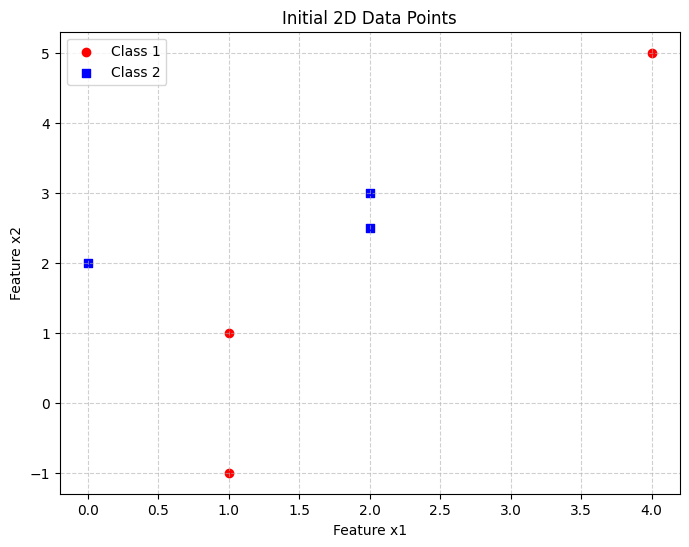


Observation: The data is not linearly separable in 2D.



In [ ]:
# Load the dataset from the file
data = np.loadtxt('/content/train-perceptron.txt')
X = data[:, :2]  # Features (x1, x2)
labels = data[:, 2]  # Class labels (1 or 2)

# Separate data into the two classes for plotting
class1 = X[labels == 1]
class2 = X[labels == 2]

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(class1[:, 0], class1[:, 1], color='red', marker='o', label='Class 1')
plt.scatter(class2[:, 0], class2[:, 1], color='blue', marker='s', label='Class 2')
plt.title('Initial 2D Data Points')
plt.xlabel('Feature x1')
plt.ylabel('Feature x2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nObservation: The data is not linearly separable in 2D.\n")


# Task 2: Transform to High-dimensional Space & Normalization

In [ ]:
# Define the phi function to map to a higher dimension
def phi_transform(X):
    """
    Transforms 2D data to a 6D feature space using a
    second-order polynomial function.
    y = [x1^2, x2^2, x1*x2, x1, x2, 1]
    """
    x1 = X[:, 0]
    x2 = X[:, 1]
    ones = np.ones(len(X))
    return np.stack([x1**2, x2**2, x1 * x2, x1, x2, ones], axis=1)

# Transform both classes
phi_class1 = phi_transform(class1)
# Normalize class 2 by multiplying by -1
phi_class2 = phi_transform(class2) * -1

# Combine into a single training set Y for the algorithm
Y = np.vstack((phi_class1, phi_class2))

# Task 3: Perceptron Algorithm Implementation

In [ ]:
def perceptron_one_at_a_time(Y, initial_weight, learning_rate, max_iterations=5000):
    """Implements the Perceptron algorithm with one-at-a-time updates."""
    w = np.copy(initial_weight)
    iterations = 0
    while iterations < max_iterations:
        iterations += 1
        misclassified_count = 0
        for y in Y:
            if np.dot(w, y) <= 0:  # Check for misclassification
                w = w + learning_rate * y  # Update weights immediately
                misclassified_count += 1

        if misclassified_count == 0:  # If a full pass has no errors, converge
            break

    return iterations

def perceptron_batch(Y, initial_weight, learning_rate, max_iterations=5000):
    """Implements the Perceptron algorithm with batch updates."""
    w = np.copy(initial_weight)
    iterations = 0
    while iterations < max_iterations:
        iterations += 1
        misclassified_sum = np.zeros_like(w)
        misclassified_count = 0

        for y in Y:
            if np.dot(w, y) <= 0:  # Check for misclassification
                misclassified_sum += y
                misclassified_count += 1

        if misclassified_count == 0: # Converged
            break

        w = w + learning_rate * misclassified_sum # Single update at the end of the pass

    return iterations

print("Perceptron functions for 'one-at-a-time' and 'batch' updates are defined.\n")

Perceptron functions for 'one-at-a-time' and 'batch' updates are defined.



# Task 4: Running Experiments & Generating Results





--- Results for Initial Weights: All Zeros ---

 Learning Rate  Iterations (One-at-a-Time)  Iterations (Many-at-a-Time)
           0.1                          94                          105
           0.2                          94                          105
           0.3                          94                           92
           0.4                          94                          105
           0.5                          94                           92
           0.6                          94                          105
           0.7                          94                          105
           0.8                          94                          105
           0.9                          94                          105
           1.0                          94                           92


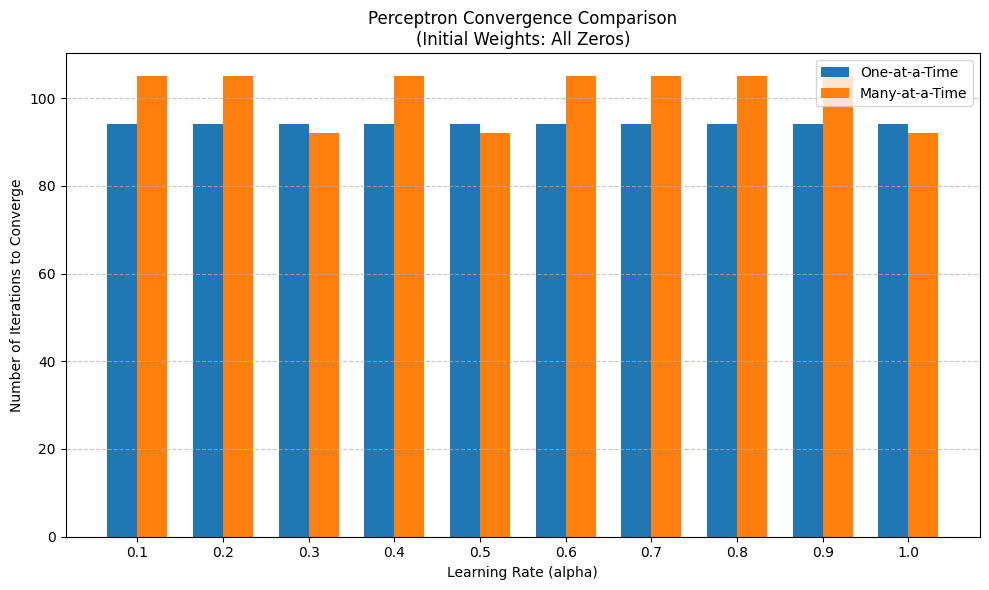



--- Results for Initial Weights: All Ones ---

 Learning Rate  Iterations (One-at-a-Time)  Iterations (Many-at-a-Time)
           0.1                           6                          102
           0.2                          92                          104
           0.3                         104                           91
           0.4                         106                          116
           0.5                          93                          105
           0.6                          93                          114
           0.7                         108                           91
           0.8                         115                           91
           0.9                          94                          105
           1.0                          94                           93


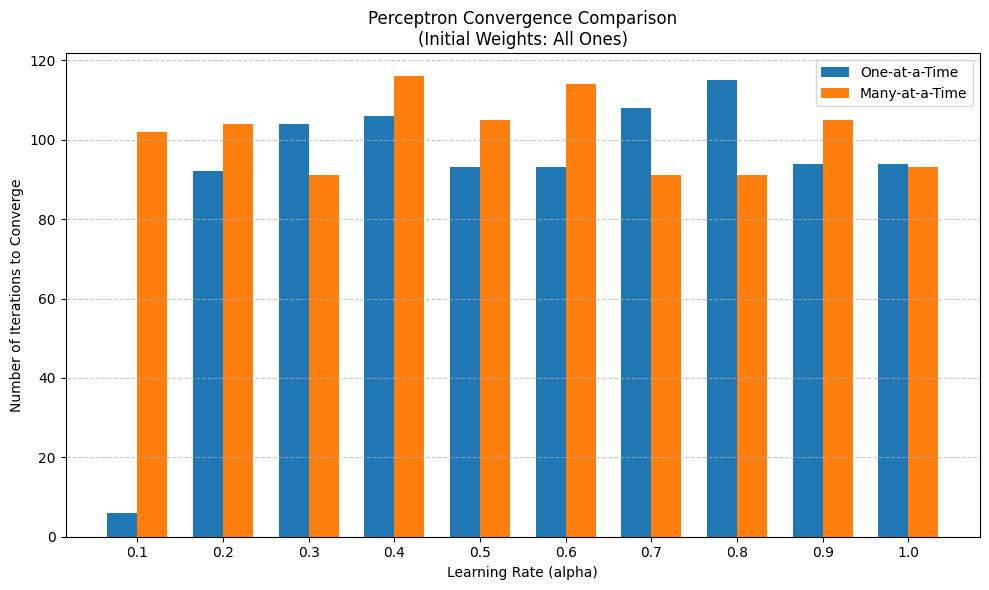



--- Results for Initial Weights: Random ---

 Learning Rate  Iterations (One-at-a-Time)  Iterations (Many-at-a-Time)
           0.1                         107                          125
           0.2                          98                           98
           0.3                         104                          100
           0.4                         101                          130
           0.5                          84                          121
           0.6                          94                          107
           0.7                         105                          121
           0.8                         106                          137
           0.9                         115                          106
           1.0                         105                          122


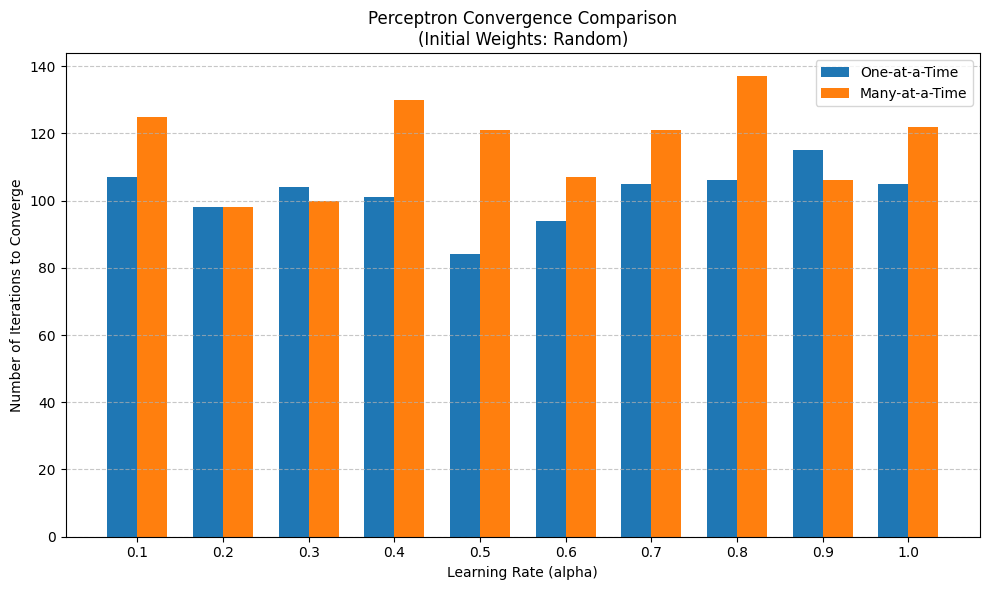

In [ ]:
# Define experiment parameters
learning_rates = np.arange(0.1, 1.1, 0.1)
np.random.seed(42) # Fixed seed for reproducibility
initial_weights_configs = {
    "All Zeros": np.zeros(Y.shape[1]),
    "All Ones": np.ones(Y.shape[1]),
    "Random": np.random.rand(Y.shape[1])
}

results = {}

# Run the experiments
for name, w_init in initial_weights_configs.items():
    results[name] = {'one_at_a_time': [], 'batch': []}
    for alpha in learning_rates:
        # One at a time
        iters_one = perceptron_one_at_a_time(Y, w_init, alpha)
        results[name]['one_at_a_time'].append(iters_one)

        # Batch (Many at a time)
        iters_batch = perceptron_batch(Y, w_init, alpha)
        results[name]['batch'].append(iters_batch)

# Display results in tables and bar charts
for name, data in results.items():
    print(f"\n\n--- Results for Initial Weights: {name} ---\n")

    # Create and display a DataFrame (table)
    df = pd.DataFrame({
        'Learning Rate': np.round(learning_rates, 1),
        'Iterations (One-at-a-Time)': data['one_at_a_time'],
        'Iterations (Many-at-a-Time)': data['batch']
    })
    print(df.to_string(index=False))

    # Create and display a bar chart
    x = np.arange(len(learning_rates))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, data['one_at_a_time'], width, label='One-at-a-Time')
    rects2 = ax.bar(x + width/2, data['batch'], width, label='Many-at-a-Time')

    ax.set_ylabel('Number of Iterations to Converge')
    ax.set_xlabel('Learning Rate (alpha)')
    ax.set_title(f'Perceptron Convergence Comparison\n(Initial Weights: {name})')
    ax.set_xticks(x)
    ax.set_xticklabels(np.round(learning_rates, 1))
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.tight_layout()
    plt.show()